#### Цель
Оформить решение из первых двух частей как самостоятельный ML-проект, добавить SVM и Naive Bayes и доказать, что эксперимент воспроизводим и не использует признаки с временной утечкой.
#### Входные артефакты
Оформи решение в репозитории online-shoppers-classification/ с src/, notebooks/, tests/, README.md, pyproject.toml, uv.lock и .gitignore. Можно вести все части в этом одном репозитории: результаты I–III должны быть доступны соответственно на ветках clf/online_shoppers/part_1, clf/online_shoppers/part_2, clf/online_shoppers/part_3. Исходные данные не коммить: код должен либо скачивать их по официальной ссылке UCI, либо принимать путь к скачанному файлу.  
Зафиксируй в коде feature policy: для real-time сценария PageValues исключается до обучения и инференса.
#### Задание
* Структура и запуск: вынеси загрузку данных, подготовку признаков, обучение, оценку и построение графиков из ноутбука в переиспользуемые модули src/. Добавь CLI или скрипт обучения с фиксированным seed и сохраняй таблицу результатов/графики в игнорируемую папку артефактов.
* Новые модели: добавь SVM минимум с линейным и RBF-ядром; другие ядра (poly, sigmoid) можно включить в сравнение. Добавь подходящий вариант Naive Bayes и обоснуй, как его предположения соотносятся с числовыми и one-hot-кодированными признаками.
* Честное сравнение: сравни SVM и Naive Bayes с логистической регрессией, деревом, случайным лесом, градиентным бустингом, XGBoost, LightGBM и CatBoost из частей I–II на одной фиксированной схеме split/CV и одних метриках. Финальную модель выбирай по PR-AUC на безопасном наборе признаков; test используй только после выбора.
* Тесты: unit-тестами проверь загрузку/валидацию схемы, исключение PageValues, отсутствие target в списке признаков и возможность обучить pipeline на небольшом фиктивном наборе данных. Тесты не должны требовать сети или скачивания датасета.
* Документация: в README.md опиши источник и лицензию данных, установку через uv, команды запуска, структуру проекта, метрики и результаты. Явно зафиксируй ограничение: PageValues нельзя применять для real-time предсказания из-за доступности признака во времени и риска target leakage.
* Качество кода: на чистой машине должны проходить uv sync, uv run ruff check ., uv run ruff format --check . и uv run pytest.

#### 1. Библиотеки и модули

In [3]:
from __future__ import annotations

import hashlib
import importlib.metadata
import io
import json
import platform
import time
import unittest
import warnings
from pathlib import Path
from tempfile import TemporaryDirectory
from urllib.request import urlopen
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from IPython.display import Markdown, display
from lightgbm import LGBMClassifier
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from threadpoolctl import threadpool_limits

In [4]:
SEED = 42
TEST_SIZE = 0.20
N_SPLITS = 5
UCI_URL = (
    "https://archive.ics.uci.edu/static/public/468/"
    "online+shoppers+purchasing+intention+dataset.zip"
)
EXPECTED_SHA256 = "b3055ee355f59134d851d32641183cb4a8b45def7124d2f50442a042f358e0d9"
PACKAGES = [
    "numpy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "xgboost",
    "lightgbm",
    "catboost",
    "threadpoolctl",
]
VERSIONS = {name: importlib.metadata.version(name) for name in PACKAGES}
VERSIONS["python"] = platform.python_version()
VERSIONS["platform"] = platform.platform()
warnings.filterwarnings("error", category=ConvergenceWarning)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
display(pd.Series(VERSIONS, name="Фактическое окружение").to_frame())

,Фактическое окружение
numpy,2.5.2
pandas,3.0.5
scikit-learn,1.9.0
matplotlib,3.11.1
xgboost,3.4.1
lightgbm,4.7.0
catboost,1.2.10
threadpoolctl,3.6.0
python,3.12.2
platform,Windows-10-10.0.19045-SP0


#### 2. Контракт данных и границы
Признаки:	Контракт для реального сервиса  
PageValues:	Всегда исключён. Связан с ценностью посещённых страниц и транзакциями; доступность на момент решения не подтверждена, есть риск proxy target leakage.  
Administrative, Informational, ProductRelated и их Duration:	Только накопленные к моменту скоринга счётчики и длительности, без дальнейшей части сессии.  
BounceRates, ExitRates:	Только исторические агрегаты, рассчитанные до скоринга; итог текущей сессии использовать нельзя.
Month, Weekend, SpecialDay	Календарь, известный заранее.  
OperatingSystems, Browser, Region, TrafficType, VisitorType:	Только сведения, уже установленные к моменту запроса.  
Revenue:	Только целевая переменная для обучения и оценки.   
Запрещённые колонки не попадают в модель; статистики preprocessing обучаются внутри folds; split фиксирован; текущий выбор не использует test.

In [5]:
NUMERIC = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "SpecialDay",
]
CATEGORICAL = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
]
FEATURES = NUMERIC + CATEGORICAL
TARGET = "Revenue"
RAW_COLUMNS = FEATURES + ["PageValues", TARGET]


def validate_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Проверь и выбери разрешённые признаки без обучения на статистиках.

    Args:
        frame: Таблица с разрешёнными колонками; лишние колонки игнорируются.

    Returns:
        Независимая таблица с фиксированным порядком признаков и Weekend 0/1.

    Raises:
        ValueError: Если схема, категории или числовые значения некорректны.
    """
    if not frame.columns.is_unique or not set(FEATURES) <= set(frame.columns):
        raise ValueError("Отсутствуют признаки или повторяются имена колонок")
    if frame.empty:
        raise ValueError("Пустая таблица")
    result = frame.loc[:, FEATURES].copy()
    for column in NUMERIC:
        values = pd.to_numeric(result[column], errors="raise")
        if np.isinf(values.to_numpy(dtype=float)).any() or (values < 0).any():
            raise ValueError(f"Недопустимые значения: {column}")
        result[column] = values.astype(float)
    for column in ["BounceRates", "ExitRates", "SpecialDay"]:
        if (result[column] > 1).any():
            raise ValueError(f"Ожидается значение от 0 до 1: {column}")
    weekend = result["Weekend"]
    if not weekend.dropna().isin([True, False, 0, 1]).all():
        raise ValueError("Weekend должен быть 0/1 или bool")
    result["Weekend"] = weekend.astype(float)
    for column in ["OperatingSystems", "Browser", "Region", "TrafficType"]:
        values = pd.to_numeric(result[column], errors="raise")
        if (
            np.isinf(values.to_numpy(dtype=float)).any()
            or (values.dropna() < 0).any()
            or (values.dropna() % 1 != 0).any()
        ):
            raise ValueError(f"Ожидается неотрицательный целый код: {column}")
        result[column] = values.astype(float)
    for column in ["Month", "VisitorType"]:
        if not result[column].dropna().map(lambda value: isinstance(value, str)).all():
            raise ValueError(f"Ожидаются строки: {column}")
        result[column] = (
            result[column].astype(object).where(result[column].notna(), np.nan)
        )
    return result


def validate_raw(frame: pd.DataFrame) -> None:
    """Проверь строгую схему исходного UCI-файла.

    Args:
        frame: Исходная таблица до удаления полных повторов.

    Raises:
        ValueError: Если схема неверна или target содержит пропуски/небинарные значения.
    """
    if set(frame.columns) != set(RAW_COLUMNS) or not frame.columns.is_unique:
        raise ValueError("Ожидается исходная схема UCI: 18 уникальных колонок")
    validate_features(frame)
    target = frame[TARGET]
    if target.isna().any() or not target.isin([False, True, 0, 1]).all():
        raise ValueError("Revenue должен быть бинарным и без пропусков")
    page = pd.to_numeric(frame["PageValues"], errors="raise")
    if np.isinf(page.to_numpy(dtype=float)).any() or (page < 0).any():
        raise ValueError("Некорректный PageValues в исходном CSV")


def load_data(path: Path, *, download: bool = False) -> pd.DataFrame:
    """Загрузи CSV локально или скачай официальный архив при явном разрешении.

    Args:
        path: Путь к CSV; при скачивании сюда записывается только нужный файл.
        download: Разрешить скачивание UCI, если локальный файл отсутствует.

    Returns:
        Проверенная исходная таблица, включая полные повторы.

    Raises:
        FileNotFoundError: Если файла нет и скачивание выключено.
        ValueError: Если CSV не соответствует контракту.
        OSError: Если чтение, сеть или запись недоступны.
    """
    if not path.is_file():
        if not download:
            raise FileNotFoundError(path)
        with urlopen(UCI_URL, timeout=60) as response:
            archive_bytes = response.read()
        with ZipFile(io.BytesIO(archive_bytes)) as archive:
            csv_bytes = archive.read("online_shoppers_intention.csv")
        # Не извлекаем произвольные пути из архива.
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_bytes(csv_bytes)
    frame = pd.read_csv(path)
    validate_raw(frame)
    return frame


class FeaturePolicy(TransformerMixin, BaseEstimator):
    """Применяй один allowlist признаков при fit и при инференсе.

    PageValues, Revenue и любые неизвестные поля отбрасываются до preprocessing.
    Обучаемых статистик у преобразования нет.
    """

    def fit(self, X: pd.DataFrame, y: object = None) -> FeaturePolicy:
        """Проверь входную схему и зафиксируй разрешённые колонки.

        Args:
            X: Входные данные, допускающие дополнительные колонки.
            y: Неиспользуемая цель для совместимости с Pipeline.

        Returns:
            Текущий преобразователь.

        Raises:
            ValueError: Если вход нарушает контракт признаков.
        """
        validate_features(X)
        self.feature_names_in_ = np.asarray(FEATURES, dtype=object)
        self.n_features_in_ = len(FEATURES)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        """Верни только разрешённые признаки в фиксированном порядке.

        Args:
            X: Новые сессии, в том числе без PageValues и Revenue.

        Returns:
            Проверенная таблица из 16 признаков.

        Raises:
            ValueError: Если обязательные признаки отсутствуют или некорректны.
        """
        return validate_features(X)

#### 3. Preprocessing и новые модели
* SVM: используем SVC(kernel="linear") и SVC(kernel="rbf"). Линейное ядро задаёт линейную границу в преобразованном пространстве. RBF - нелинейную границу; "C" управляет штрафом за нарушения, gamma — локальностью влияния объектов. Числа стандартизируются внутри pipeline. Для AP/ROC AUC достаточно decision_function: его значения не являются вероятностями, рабочий порог может быть отрицательным. Калибровка вероятностей - отдельный будущий train-only эксперимент.
* BernoulliNB: числовая ветка - imputer → разбиение на квантильные интервалы → one-hot; категориальная - imputer → one-hot. На вход NB идут только 0/1. Границы интервалов обучаются на fit-фолде, параметры сглаживания alpha сравниваются по CV. Это соответствует бинарной модели признаков, в отличие от GaussianNB на сырых one-hot. Однако индикаторы одной категории взаимоисключающие, а длительность связана с числом страниц: предположение условной независимости нарушено. NB - быстрый приближённый baseline; дискретизация теряет точность числовых величин, вероятности могут быть плохо откалиброваны. MultinomialNB на стандартизованных числах с отрицательными значениями не подходит.
* Категориальная обработка всех бустингов (включая CatBoost) - общий one-hot. Это честное сравнение конкретных pipeline, а не доказательство предельного качества каждой библиотеки. Нативный CatBoost был бы отдельным экспериментом.

In [6]:
def make_pipeline(model: BaseEstimator, *, mode: str = "tree") -> Pipeline:
    """Собери preprocessing и классификатор с обязательной feature policy.

    Args:
        model: Необученный классификатор scikit-learn-совместимого API.
        mode: tree — числа без scaling; scaled — StandardScaler; binary — интервалы.

    Returns:
        Независимый pipeline, который можно клонировать для каждого фолда.

    Raises:
        ValueError: Если указан неизвестный режим обработки.
    """
    if mode not in {"tree", "scaled", "binary"}:
        raise ValueError(f"Неизвестный режим: {mode}")
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median", keep_empty_features=True))
    ]
    if mode == "scaled":
        numeric_steps.append(("scaler", StandardScaler()))
    elif mode == "binary":
        numeric_steps.append(
            (
                "bins",
                KBinsDiscretizer(
                    n_bins=4,
                    encode="onehot-dense",
                    strategy="quantile",
                    quantile_method="averaged_inverted_cdf",
                    subsample=None,
                    random_state=SEED,
                ),
            )
        )
    categorical = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(strategy="most_frequent", keep_empty_features=True),
            ),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )
    preprocessor = ColumnTransformer(
        [
            ("num", Pipeline(numeric_steps), NUMERIC),
            ("cat", categorical, CATEGORICAL),
        ],
        remainder="drop",
    )
    return Pipeline(
        [
            ("policy", FeaturePolicy()),
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


def build_candidates() -> dict[str, tuple[Pipeline, dict]]:
    """Создай модели и заранее заданные компактные сетки поиска.

    Returns:
        Словарь имя → (pipeline, сетка параметров); пустая сетка означает baseline.
    """
    from xgboost import XGBClassifier

    return {
        "Dummy": (make_pipeline(DummyClassifier(strategy="prior")), {}),
        "LogisticRegression": (
            make_pipeline(
                LogisticRegression(
                    C=1.0,
                    max_iter=5000,
                    random_state=SEED,
                ),
                mode="scaled",
            ),
            {},
        ),
        "DecisionTree": (
            make_pipeline(
                DecisionTreeClassifier(
                    max_depth=5,
                    min_samples_leaf=50,
                    random_state=SEED,
                )
            ),
            {},
        ),
        "RandomForest": (
            make_pipeline(
                RandomForestClassifier(
                    n_estimators=200,
                    min_samples_leaf=2,
                    random_state=SEED,
                    n_jobs=1,
                )
            ),
            {"model__max_depth": [8, None]},
        ),
        "GradientBoosting": (
            make_pipeline(
                GradientBoostingClassifier(
                    n_estimators=150,
                    learning_rate=0.05,
                    min_samples_leaf=20,
                    random_state=SEED,
                )
            ),
            {"model__max_depth": [2, 3]},
        ),
        "XGBoost": (
            make_pipeline(
                XGBClassifier(
                    n_estimators=200,
                    learning_rate=0.05,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    tree_method="hist",
                    n_jobs=1,
                    random_state=SEED,
                    verbosity=0,
                )
            ),
            {"model__max_depth": [2, 4]},
        ),
        "LightGBM": (
            make_pipeline(
                LGBMClassifier(
                    n_estimators=200,
                    learning_rate=0.05,
                    min_child_samples=30,
                    random_state=SEED,
                    n_jobs=1,
                    deterministic=True,
                    force_col_wise=True,
                    verbosity=-1,
                )
            ),
            {"model__num_leaves": [7, 15]},
        ),
        "CatBoost": (
            make_pipeline(
                CatBoostClassifier(
                    iterations=200,
                    learning_rate=0.05,
                    random_seed=SEED,
                    thread_count=1,
                    verbose=False,
                    allow_writing_files=False,
                    loss_function="Logloss",
                )
            ),
            {"model__depth": [4, 6]},
        ),
        "SVM_linear": (
            make_pipeline(
                SVC(
                    kernel="linear",
                    cache_size=512,
                    random_state=SEED,
                    max_iter=1000000,
                ),
                mode="scaled",
            ),
            {"model__C": [0.1, 1.0]},
        ),
        "SVM_rbf": (
            make_pipeline(
                SVC(
                    kernel="rbf",
                    cache_size=512,
                    random_state=SEED,
                    max_iter=1000000,
                ),
                mode="scaled",
            ),
            {"model__C": [1.0, 10.0], "model__gamma": ["scale", 0.01]},
        ),
        "BernoulliNB": (
            make_pipeline(BernoulliNB(binarize=None), mode="binary"),
            {"model__alpha": [0.1, 1.0]},
        ),
    }

#### 4. Метрики и выбор
* Основная метрика - Average Precision (average_precision_score) = столбец AP. Это конкретное определение метрики PR-кривой; AP не равна трапецеидальной площади auc(recall, precision). ROC AUC, precision, recall, F1 и confusion matrix дополняют AP.
* Порядок: фиксируем split и folds → на train подбираем параметры → выбираем алгоритм по mean CV AP → строим OOF только выбранного pipeline → фиксируем порог максимального OOF F1 → проверяем повторный запуск → обучаем на всём train → открываем test один раз для выбранной модели.
* В сравнительной CV-таблице precision/recall/F1 считаются при штатном predict каждой модели (обычно 0.5 для вероятностей, 0 для SVM). Отдельно показываем рабочие OOF/test метрики выбранной модели с настроенным порогом. Не смешиваем эти два режима.
* Границы честности: CV участвует в подборе параметров и выборе алгоритма, поэтому её максимум оптимистичен. OOF для уже выбранных параметров тоже не является nested-CV: validation-метки косвенно повлияли на выбор параметров. Настроенный на этих OOF порог и OOF F1 - показатели этапа разработки, не независимая оценка. Это допустимо для train-only настройки; независимую оценку даёт только последующее внешнее тестирование с оговоркой об уже виденном test.

In [7]:
def positive_scores(fitted: Pipeline, features: pd.DataFrame) -> np.ndarray:
    """Получи score положительного класса без требования вероятностной калибровки.

    Args:
        fitted: Обученный pipeline для классов 0 и 1.
        features: Сессии для предсказания.

    Returns:
        Одномерный массив вероятностей или SVM decision scores.

    Raises:
        ValueError: Если классы или вычисленные scores некорректны.
    """
    if not np.array_equal(fitted.classes_, [0, 1]):
        raise ValueError("Ожидаются классы [0, 1]")
    if isinstance(fitted.named_steps["model"], SVC):
        score = fitted.decision_function(features)
    else:
        score = fitted.predict_proba(features)[:, 1]
    score = np.asarray(score, dtype=float)
    if score.shape != (len(features),) or not np.isfinite(score).all():
        raise ValueError("Некорректные scores")
    return score


def evaluate_scores(target: pd.Series, score: np.ndarray, threshold: float) -> dict:
    """Оцени ранжирование и решения при заранее фиксированном пороге.

    Args:
        target: Истинные метки 0/1, оба класса обязательны для ROC AUC.
        score: Scores положительного класса.
        threshold: Порог решения; значения выше или равные означают класс 1.

    Returns:
        Метрики, элементы confusion matrix и доля положительных решений.
    """
    predicted = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(target, predicted, labels=[0, 1]).ravel()
    return {
        "AP": float(average_precision_score(target, score)),
        "ROC_AUC": float(roc_auc_score(target, score)),
        "precision": float(precision_score(target, predicted, zero_division=0)),
        "recall": float(recall_score(target, predicted, zero_division=0)),
        "F1": float(f1_score(target, predicted, zero_division=0)),
        "threshold": float(threshold),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "positive_rate": float(predicted.mean()),
    }


def choose_threshold(target: pd.Series, score: np.ndarray) -> float:
    """Найди порог максимального F1 на train OOF с фиксированным правилом ничьей.

    Args:
        target: Метки обучающей выборки.
        score: OOF-scores в том же порядке.

    Returns:
        Наибольший порог среди равных максимумов F1.
    """
    precision, recall, thresholds = precision_recall_curve(target, score)
    denominator = precision[:-1] + recall[:-1]
    f1 = np.divide(
        2 * precision[:-1] * recall[:-1],
        denominator,
        out=np.zeros_like(denominator),
        where=denominator > 0,
    )
    return float(thresholds[np.flatnonzero(f1 == f1.max())[-1]])


def collect_oof(
    pipeline: Pipeline,
    features: pd.DataFrame,
    target: pd.Series,
    folds: list[tuple[np.ndarray, np.ndarray]],
) -> np.ndarray:
    """Получай OOF-scores при независимом fit preprocessing на каждом фолде.

    Args:
        pipeline: Зафиксированный необученный pipeline.
        features: Только train-часть данных.
        target: Train-метки в порядке features.
        folds: Позиционные индексы fit/validation внутри train.

    Returns:
        OOF-scores, по одному на каждую строку train.

    Raises:
        ValueError: Если folds пересекаются или не покрывают train ровно один раз.
    """
    scores = np.full(len(target), np.nan)
    hits = np.zeros(len(target), dtype=int)
    for fit_idx, valid_idx in folds:
        if np.intersect1d(fit_idx, valid_idx).size:
            raise ValueError("Пересечение fit и validation")
        with threadpool_limits(limits=1):
            fitted = clone(pipeline).fit(features.iloc[fit_idx], target.iloc[fit_idx])
            scores[valid_idx] = positive_scores(fitted, features.iloc[valid_idx])
        hits[valid_idx] += 1
    if not np.all(hits == 1) or not np.isfinite(scores).all():
        raise ValueError("Каждая train-строка должна иметь один OOF-score")
    return scores

#### 5. Переиспользуемый эксперимент
Функция ниже принимает только train, а не всю таблицу или test: это делает зависимость выбора от test явной и проверяемой. Ошибки зависимостей и обучения не пропускаются. Все модели работают на CPU, с одним потоком; время зависит от машины и не считается детерминированным результатом.

In [8]:
def compare_models(
    features: pd.DataFrame,
    target: pd.Series,
    folds: list[tuple[np.ndarray, np.ndarray]],
    artifact_dir: Path,
) -> tuple[pd.DataFrame, dict[str, Pipeline]]:
    """Сравни все кандидаты по одним folds и сохрани полный журнал поиска.

    Args:
        features: Только train-признаки.
        target: Только train-метки.
        folds: Общие фиксированные CV-разбиения.
        artifact_dir: Каталог для таблиц поиска, исключаемый из Git.

    Returns:
        Таблица лучших конфигураций и соответствующие необученные pipeline.
    """
    artifact_dir.mkdir(parents=True, exist_ok=True)
    rows, selected = [], {}
    scoring = {
        "AP": "average_precision",
        "ROC_AUC": "roc_auc",
        "precision": "precision",
        "recall": "recall",
        "F1": "f1",
    }
    for name, (pipeline, grid) in build_candidates().items():
        started = time.perf_counter()
        search = GridSearchCV(
            pipeline,
            grid,
            scoring=scoring,
            refit="AP",
            cv=folds,
            n_jobs=1,
            error_score="raise",
        )
        with threadpool_limits(limits=1):
            search.fit(features, target)
        results = pd.DataFrame(search.cv_results_)
        results.to_csv(artifact_dir / f"search_{name}.csv", index=False)
        best = results.iloc[search.best_index_]
        row = {
            "model": name,
            "params": json.dumps(search.best_params_, sort_keys=True),
            "search_seconds": time.perf_counter() - started,
            "fit_seconds": float(best["mean_fit_time"]),
            "score_seconds": float(best["mean_score_time"]),
        }
        for metric in scoring:
            row[f"CV_{metric}_mean"] = float(best[f"mean_test_{metric}"])
            row[f"CV_{metric}_std"] = float(best[f"std_test_{metric}"])
        rows.append(row)
        selected[name] = clone(pipeline).set_params(**search.best_params_)
        print(
            f"{name}: CV AP={row['CV_AP_mean']:.4f}; {row['search_seconds']:.1f} s",
            flush=True,
        )
    table = (
        pd.DataFrame(rows)
        .sort_values(
            ["CV_AP_mean", "model"],
            ascending=[False, True],
            kind="stable",
        )
        .set_index("model")
    )
    table.to_csv(artifact_dir / "cv_comparison.csv")
    return table, selected


def plot_results(
    comparison: pd.DataFrame,
    target: pd.Series,
    score: np.ndarray,
    threshold: float,
    name: str,
    artifact_dir: Path,
) -> None:
    """Сохрани сравнение CV и итоговые кривые единственной выбранной модели.

    Args:
        comparison: Итоговая CV-таблица всех моделей.
        target: Метки финального test.
        score: Уже рассчитанные test-scores.
        threshold: Порог, ранее выбранный на train OOF.
        name: Имя выбранной модели.
        artifact_dir: Каталог PNG-артефактов.
    """
    ordered = comparison.sort_values("CV_AP_mean")
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(ordered.index, ordered["CV_AP_mean"], xerr=ordered["CV_AP_std"])
    ax.set(xlabel="Mean CV Average Precision ± fold std", title="Train CV comparison")
    fig.tight_layout()
    fig.savefig(artifact_dir / "cv_comparison.png", bbox_inches="tight")
    plt.show()
    precision, recall, _ = precision_recall_curve(target, score)
    fpr, tpr, _ = roc_curve(target, score)
    metrics = evaluate_scores(target, score, threshold)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].step(recall, precision, where="post")
    axes[0].axhline(target.mean(), linestyle="--", color="gray")
    axes[0].scatter(metrics["recall"], metrics["precision"], color="red")
    axes[0].set(
        xlabel="Recall", ylabel="Precision", title=f"Test AP={metrics['AP']:.3f}"
    )
    axes[1].plot(fpr, tpr)
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1].set(
        xlabel="FPR", ylabel="TPR", title=f"Test ROC AUC={metrics['ROC_AUC']:.3f}"
    )
    matrix = np.array([[metrics["TN"], metrics["FP"]], [metrics["FN"], metrics["TP"]]])
    axes[2].imshow(matrix, cmap="Blues")
    for (i, j), value in np.ndenumerate(matrix):
        axes[2].text(j, i, str(value), ha="center", va="center", color="darkred")
    axes[2].set(
        xticks=[0, 1],
        yticks=[0, 1],
        xlabel="Predicted",
        ylabel="Actual",
        title="Confusion matrix",
    )
    fig.suptitle(f"{name}; threshold selected on train OOF")
    fig.tight_layout()
    fig.savefig(artifact_dir / "selected_test.png", bbox_inches="tight")
    plt.show()

#### 6. Unit-тесты без сети и UCI
Проверяем локальный CSV и ошибки схемы, target, исключение PageValues при fit и inference, устойчивость к изменению запрещённых колонок, обучение всех 11 pipeline, бинарный вход NB и отсутствие подглядывания imputer в validation. Эти unittest.TestCase совместимы с pytest: на этапе проекта переносим их в tests/, добавляем импорты из пакета. Никаких вызовов загрузчика с download=True в тестах нет.

In [9]:
def synthetic_data(n: int = 80) -> pd.DataFrame:
    """Создай маленький фиктивный датасет без обращения к сети.

    Args:
        n: Число строк, не меньше 20.

    Returns:
        Таблица исходной схемы с двумя классами и разнообразными признаками.

    Raises:
        ValueError: Если запрошено меньше 20 строк.
    """
    if n < 20:
        raise ValueError("Нужно минимум 20 строк")
    rng = np.random.default_rng(SEED)
    frame = pd.DataFrame({column: rng.uniform(0, 1, n) for column in NUMERIC})
    for column in ["OperatingSystems", "Browser", "Region", "TrafficType"]:
        frame[column] = rng.integers(1, 4, n)
    frame["Month"] = np.where(np.arange(n) % 2, "May", "Nov")
    frame["VisitorType"] = np.where(
        np.arange(n) % 3, "Returning_Visitor", "New_Visitor"
    )
    frame["Weekend"] = np.arange(n) % 2 == 0
    frame["PageValues"] = rng.uniform(0, 100, n)
    frame[TARGET] = (frame["ProductRelated"] > 0.6).astype(int)
    return frame.loc[:, RAW_COLUMNS]


class NotebookTests(unittest.TestCase):
    """Проверь контракт данных и обучение pipeline на фиктивных сессиях."""

    def test_local_loader(self) -> None:
        """Проверь CSV roundtrip и отсутствие неявного скачивания."""
        with TemporaryDirectory() as directory:
            path = Path(directory) / "fixture.csv"
            source = synthetic_data()
            source.to_csv(path, index=False)
            loaded = load_data(path)
            self.assertEqual(loaded.shape, source.shape)
            with self.assertRaises(FileNotFoundError):
                load_data(Path(directory) / "missing.csv")

    def test_invalid_schema_and_target(self) -> None:
        """Отклони пустую таблицу, неверную схему, target и бесконечности."""
        source = synthetic_data()
        cases = [
            source.iloc[:0],
            source.drop(columns="Browser"),
            source.assign(extra=1),
            source.assign(Revenue=2),
            source.assign(Revenue=np.nan),
            source.assign(BounceRates=np.inf),
            source.assign(Weekend="sometimes"),
            source.assign(Browser=1.5),
        ]
        for frame in cases:
            with (
                self.subTest(columns=list(frame.columns)),
                self.assertRaises(ValueError),
            ):
                validate_raw(frame)

    def test_policy_at_fit_and_inference(self) -> None:
        """Докажи инвариантность модели к запрещённым признакам."""
        source = synthetic_data()
        pipeline = make_pipeline(LogisticRegression(max_iter=5000), mode="scaled")
        first = clone(pipeline).fit(source, source[TARGET])
        changed = source.assign(
            PageValues=1e12, Revenue=1 - source[TARGET], unknown=999
        )
        second = clone(pipeline).fit(changed, source[TARGET])
        expected = positive_scores(first, source)
        np.testing.assert_allclose(
            expected, positive_scores(first, changed), atol=0, rtol=0
        )
        np.testing.assert_allclose(
            expected, positive_scores(second, changed), atol=0, rtol=0
        )
        np.testing.assert_allclose(expected, positive_scores(first, source[FEATURES]))
        transformed = first.named_steps["policy"].transform(source)
        self.assertEqual(list(transformed.columns), FEATURES)
        self.assertNotIn(TARGET, transformed.columns)
        self.assertNotIn("PageValues", transformed.columns)
        self.assertFalse(
            any(
                "PageValues" in name or "Revenue" in name
                for name in first.named_steps["preprocessor"].get_feature_names_out()
            )
        )

    def test_all_models_fit(self) -> None:
        """Обучи каждое семейство моделей на синтетических данных."""
        source = synthetic_data()
        for name, (pipeline, _) in build_candidates().items():
            with self.subTest(model=name), threadpool_limits(limits=1):
                fitted = clone(pipeline).fit(source, source[TARGET])
                self.assertEqual(positive_scores(fitted, source).shape, (len(source),))
                if name == "BernoulliNB":
                    transformed = fitted[:-1].transform(source)
                    self.assertTrue(np.isin(transformed, [0, 1]).all())

    def test_imputer_fit_only_on_training_rows(self) -> None:
        """Убедись, что transform validation не меняет статистики imputer."""
        source = synthetic_data()
        source.loc[:9, "Administrative"] = np.nan
        train, validation = source.iloc[:60].copy(), source.iloc[60:].copy()
        pipeline = make_pipeline(LogisticRegression(max_iter=5000), mode="scaled")
        fitted = pipeline.fit(train, train[TARGET])
        imputer = (
            fitted.named_steps["preprocessor"]
            .named_transformers_["num"]
            .named_steps["imputer"]
        )
        before = imputer.statistics_.copy()
        self.assertAlmostEqual(before[0], train["Administrative"].median())
        validation["Administrative"] = 1e9
        fitted.predict(validation)
        np.testing.assert_array_equal(before, imputer.statistics_)

    def test_unknown_categories_and_threshold(self) -> None:
        """Проверь новые категории и выбор порога на простом примере."""
        source = synthetic_data()
        fitted = make_pipeline(BernoulliNB(binarize=None), mode="binary").fit(
            source, source[TARGET]
        )
        novel = source.iloc[:3].copy()
        novel["Month"] = "unseen"
        self.assertTrue(np.isfinite(positive_scores(fitted, novel)).all())
        target = pd.Series([0, 0, 1, 1])
        score = np.array([-2.0, -1.0, 1.0, 2.0])
        self.assertEqual(choose_threshold(target, score), 1.0)


suite = unittest.defaultTestLoader.loadTestsFromTestCase(NotebookTests)
test_result = unittest.TextTestRunner(verbosity=2).run(suite)
if not test_result.wasSuccessful():
    raise RuntimeError("Unit-тесты не прошли; эксперимент остановлен")

test_all_models_fit (__main__.NotebookTests.test_all_models_fit)
Обучи каждое семейство моделей на синтетических данных. ... ok
test_imputer_fit_only_on_training_rows (__main__.NotebookTests.test_imputer_fit_only_on_training_rows)
Убедись, что transform validation не меняет статистики imputer. ... ok
test_invalid_schema_and_target (__main__.NotebookTests.test_invalid_schema_and_target)
Отклони пустую таблицу, неверную схему, target и бесконечности. ... ok
test_local_loader (__main__.NotebookTests.test_local_loader)
Проверь CSV roundtrip и отсутствие неявного скачивания. ... ok
test_policy_at_fit_and_inference (__main__.NotebookTests.test_policy_at_fit_and_inference)
Докажи инвариантность модели к запрещённым признакам. ... ok
test_unknown_categories_and_threshold (__main__.NotebookTests.test_unknown_categories_and_threshold)
Проверь новые категории и выбор порога на простом примере. ... ok

----------------------------------------------------------------------
Ran 6 tests in 35.302s

O

#### 7. Данные, split и контроль происхождения
Если передать существующий DATA_PATH, сеть не нужна. При запуске из notebooks/ используется корень на уровень выше. Воспроизводим тот же CSV: контрольная сумма взята из вывода части I. Для иного файла останавливаемся, чтобы не выдавать другое разбиение за прежнее.  
Полные повторы удаляем как раньше: метрики относятся к уникальным строкам, а не исходному потоку. Если останутся одинаковые разрешённые X, то код остановится: потребуется отдельный согласованный group-split

In [10]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "data/online_shoppers_intention/online_shoppers_intention.csv"
ARTIFACT_DIR = ROOT / "artifacts/part_3"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
raw = load_data(DATA_PATH, download=True)
data_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
if data_sha256 != EXPECTED_SHA256:
    raise ValueError("CSV отличается от частей I–II; проверь источник и новый протокол")
data = raw.drop_duplicates().reset_index(drop=True)
X = validate_features(data)
y = data[TARGET].astype(int)
if X.duplicated().any():
    raise ValueError("Повторяются разрешённые X; нужен отдельный групповой протокол")
train_ids, test_ids = train_test_split(
    np.arange(len(data)),
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED,
)
X_train, y_train = X.iloc[train_ids].copy(), y.iloc[train_ids].copy()
# test_ids сохраняем, но test-прогнозы и метрики пока не вычисляем.
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
folds = list(cv.split(X_train, y_train))
assert set(train_ids).isdisjoint(test_ids)
hits = np.zeros(len(train_ids), dtype=int)
for fit_idx, valid_idx in folds:
    assert not np.intersect1d(fit_idx, valid_idx).size
    hits[valid_idx] += 1
assert np.all(hits == 1)
split_manifest = {
    "seed": SEED,
    "test_size": TEST_SIZE,
    "n_splits": N_SPLITS,
    "raw_sha256": data_sha256,
    "deduplication": "full rows; keep first; reset index",
    "train_ids": train_ids.tolist(),
    "test_ids": test_ids.tolist(),
    "folds": [{"fit": fit.tolist(), "valid": valid.tolist()} for fit, valid in folds],
    "features": FEATURES,
}
split_text = json.dumps(split_manifest, sort_keys=True)
split_sha256 = hashlib.sha256(split_text.encode()).hexdigest()
(ARTIFACT_DIR / "split_manifest.json").write_text(split_text, encoding="utf-8")
print(
    f"Raw: {len(raw)}; deduplicated: {len(data)}; train: {len(train_ids)}; test: {len(test_ids)}"
)
print(
    "Train purchases:",
    int(y_train.sum()),
    "; train prevalence:",
    round(y_train.mean(), 4),
)
print("CSV SHA-256:", data_sha256)
print("Split SHA-256:", split_sha256)

Raw: 12330; deduplicated: 12205; train: 9764; test: 2441
Train purchases: 1526 ; train prevalence: 0.1563
CSV SHA-256: b3055ee355f59134d851d32641183cb4a8b45def7124d2f50442a042f358e0d9
Split SHA-256: 98d0ebd747b8e63e461b8f443bebdc6064015b19ad403c90bf1f15f542e2910f


#### 8. Сравнение всех моделей - только train
LogisticRegression и DecisionTree сохраняют baseline-параметры части I. Остальные используют небольшие заранее заданные сетки. Отличие бюджета от части II явно зафиксировано: её 16 случайных конфигураций не выдаются за эти результаты. Ошибки и предупреждения о несходимости не скрываем. Для NB предупреждение об объединении слишком узких квантильных интервалов ожидаемо на признаках с множеством нулей: эффективное число интервалов может быть меньше четырёх.

In [11]:
comparison, tuned_pipelines = compare_models(X_train, y_train, folds, ARTIFACT_DIR)
# Dummy — контрольная линия, а не кандидат для финального бизнес-решения.
selected_name = comparison.drop(index="Dummy").index[0]
selected_pipeline = tuned_pipelines[selected_name]
display(comparison)
print("Выбрана по CV AP до открытия test:", selected_name)

e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\metri

Dummy: CV AP=0.1563; 12.5 s
LogisticRegression: CV AP=0.3278; 8.6 s
DecisionTree: CV AP=0.3252; 6.3 s


e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


RandomForest: CV AP=0.3832; 68.3 s
GradientBoosting: CV AP=0.3715; 98.4 s
XGBoost: CV AP=0.3764; 37.2 s
LightGBM: CV AP=0.3790; 16.9 s
CatBoost: CV AP=0.3735; 49.4 s


e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\metri

...

e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\preprocessing\_discretizat

BernoulliNB: CV AP=0.3174; 20.5 s


e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
e:\Ian\classic_ml\.venv\Lib\site-packages\sklearn\preprocessing\_discretizat

,params,search_seconds,fit_seconds,score_seconds,CV_AP_mean,CV_AP_std,CV_ROC_AUC_mean,CV_ROC_AUC_std,CV_precision_mean,CV_precision_std,CV_recall_mean,CV_recall_std,CV_F1_mean,CV_F1_std
model,,,,,,,,,,,,,,
RandomForest,"{""model__max_depth"": null}",68.262436,5.929143,0.566089,0.383186,0.031593,0.772488,0.017348,0.580749,0.109708,0.058986,0.013627,0.107054,0.024294
LightGBM,"{""model__num_leaves"": 7}",16.941549,0.810998,0.267009,0.378976,0.020712,0.776970,0.014206,0.568236,0.101094,0.055056,0.012018,0.100105,0.020954
XGBoost,"{""model__max_depth"": 4}",37.150660,1.491832,0.176251,0.376382,0.019464,0.776740,0.012974,0.519340,0.068747,0.064884,0.014456,0.115182,0.024473
CatBoost,"{""model__depth"": 6}",49.388712,4.522283,0.177110,0.373541,0.028375,0.776822,0.017968,0.514259,0.101369,0.075373,0.024477,0.130704,0.040514
GradientBoosting,"{""model__max_depth"": 3}",98.401914,8.718080,0.130598,0.371543,0.023034,0.773083,0.014967,0.502637,0.071512,0.051778,0.007910,0.093575,0.013278
LogisticRegression,{},8.629969,1.155342,0.405523,0.327799,0.026776,0.743365,0.022540,0.486863,0.077245,0.032110,0.003820,0.060120,0.006771
DecisionTree,{},6.338304,0.622419,0.404341,0.325228,0.017796,0.739218,0.015239,0.477345,0.098922,0.064886,0.022105,0.113585,0.036374
BernoulliNB,"{""model__alpha"": 1.0}",20.498027,1.114789,0.812222,0.317447,0.029955,0.738065,0.018982,0.285950,0.011756,0.559638,0.016131,0.378434,0.013234
SVM_rbf,"{""model__C"": 1.0, ""model__gamma"": ""scale""}",256.861868,10.560029,4.774791,0.300687,0.013966,0.680028,0.012899,0.300000,0.400000,0.003279,0.004147,0.006464,0.008161


Выбрана по CV AP до открытия test: RandomForest


#### 9. OOF-порог и воспроизводимость до открытия test
Повторяем split и CV, дважды независимо строим OOF выбранной модели, дважды обучаем её на полном train. Проверяем индексы, scores и рабочий порог. Это непосредственная проверка выбранного pipeline в данном окружении.  
Для полной повторной проверки запускаем весь ноутбук заново и сравниваем raw_sha256, split_sha256, deterministic_signature, параметры и CV-таблицу (без времени).

In [12]:
repeat_train, repeat_test = train_test_split(
    np.arange(len(data)),
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED,
)
np.testing.assert_array_equal(train_ids, repeat_train)
np.testing.assert_array_equal(test_ids, repeat_test)
repeat_folds = list(
    StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED).split(
        X_train, y_train
    )
)
for (fit, valid), (fit_again, valid_again) in zip(folds, repeat_folds, strict=True):
    np.testing.assert_array_equal(fit, fit_again)
    np.testing.assert_array_equal(valid, valid_again)
oof_scores = collect_oof(selected_pipeline, X_train, y_train, folds)
repeat_oof = collect_oof(selected_pipeline, X_train, y_train, repeat_folds)
np.testing.assert_allclose(oof_scores, repeat_oof, rtol=1e-10, atol=1e-12)
threshold = choose_threshold(y_train, oof_scores)
assert threshold == choose_threshold(y_train, repeat_oof)
with threadpool_limits(limits=1):
    final_model = clone(selected_pipeline).fit(X_train, y_train)
    repeated_model = clone(selected_pipeline).fit(X_train, y_train)
    reference_scores = positive_scores(final_model, X_train)
    repeated_scores = positive_scores(repeated_model, X_train)
np.testing.assert_allclose(reference_scores, repeated_scores, rtol=1e-10, atol=1e-12)
pd.DataFrame(
    {"row_id": train_ids, "target": y_train.to_numpy(), "score": oof_scores}
).to_csv(
    ARTIFACT_DIR / "selected_oof.csv",
    index=False,
)
selection_record = {
    "model": selected_name,
    "parameters": json.loads(comparison.loc[selected_name, "params"]),
    "selection_metric": "mean CV average_precision",
    "CV_AP": float(comparison.loc[selected_name, "CV_AP_mean"]),
    "threshold": threshold,
    "threshold_rule": "maximum train OOF F1; largest threshold on tie",
    "score_kind": "decision_function"
    if isinstance(final_model.named_steps["model"], SVC)
    else "predict_proba",
    "versions": VERSIONS,
    "raw_sha256": data_sha256,
    "split_sha256": split_sha256,
    "oof_repeat_max_abs_diff": float(np.max(np.abs(oof_scores - repeat_oof))),
    "refit_repeat_max_abs_diff": float(
        np.max(np.abs(reference_scores - repeated_scores))
    ),
    "real_time_limitation": (
        "CSV has no point-in-time snapshots; "
        "availability of retained features is conditional"
    ),
    "prior_test_exposure": "same test was reported in parts I and II",
}
deterministic_columns = [
    column for column in comparison if not column.endswith("seconds")
]
signature_payload = (
    comparison[deterministic_columns].to_csv(float_format="%.10g") + split_sha256
)
selection_record["deterministic_signature"] = hashlib.sha256(
    signature_payload.encode()
).hexdigest()
# Этот файл фиксируется ДО вычисления test-метрик.
(ARTIFACT_DIR / "selection_before_test.json").write_text(
    json.dumps(selection_record, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
display(
    pd.Series(
        evaluate_scores(y_train, oof_scores, threshold), name="Train OOF / development"
    )
)
print(
    "Reproducibility checks passed; selected:", selected_name, "; threshold:", threshold
)

AP                  0.373318
ROC_AUC             0.771622
precision           0.322124
recall              0.596330
F1                  0.418295
threshold           0.216632
TN               6323.000000
FP               1915.000000
FN                616.000000
TP                910.000000
positive_rate       0.289328
Name: Train OOF / development, dtype: float64

Reproducibility checks passed; selected: RandomForest ; threshold: 0.21663162596825716


#### 10. Единственная итоговая test-оценка
Оцениваем только выбранную модель. Все семейства уже сравнены на одинаковых folds; дополнительная test-гонка не нужна. Если результат не устраивает, сохраняем его как итог текущего протокола; не выбираем другого победителя по test.

,AP,ROC_AUC,precision,recall,F1,threshold,TN,FP,FN,TP,positive_rate
model,,,,,,,,,,,
RandomForest,0.38049,0.785015,0.337931,0.641361,0.442638,0.216632,1579,480,137,245,0.297009


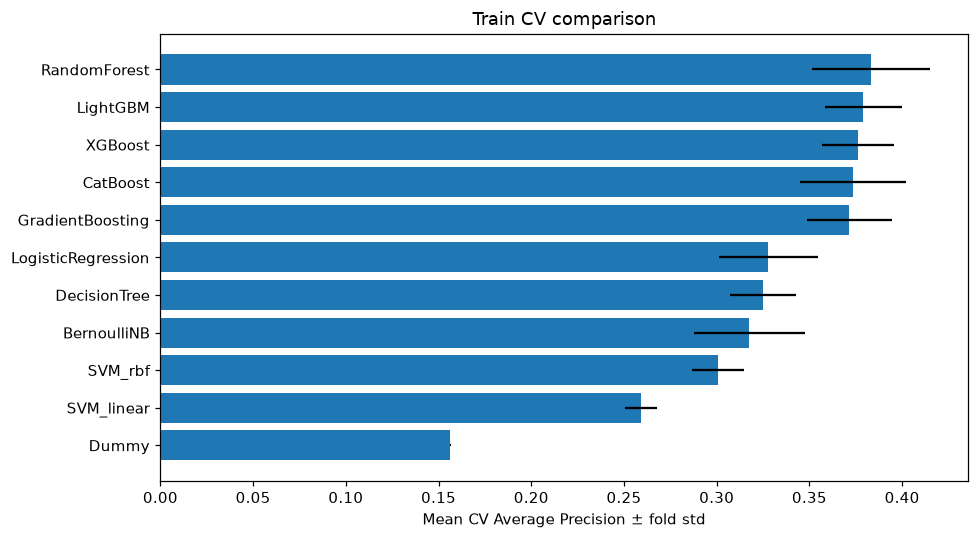

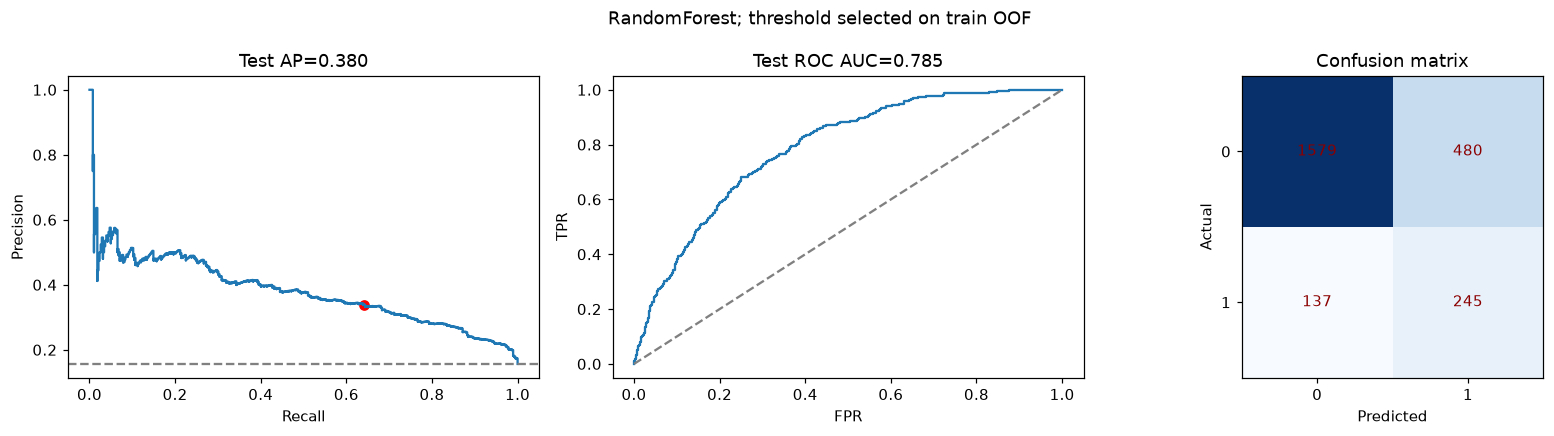

In [13]:
X_test, y_test = X.iloc[test_ids].copy(), y.iloc[test_ids].copy()
with threadpool_limits(limits=1):
    test_scores = positive_scores(final_model, X_test)
test_metrics = evaluate_scores(y_test, test_scores, threshold)
test_table = pd.DataFrame([{"model": selected_name, **test_metrics}]).set_index("model")
test_table.to_csv(ARTIFACT_DIR / "selected_test_metrics.csv")
pd.DataFrame(
    {
        "row_id": test_ids,
        "target": y_test.to_numpy(),
        "score": test_scores,
        "prediction": (test_scores >= threshold).astype(int),
    }
).to_csv(
    ARTIFACT_DIR / "selected_test_predictions.csv",
    index=False,
)
display(test_table)
plot_results(comparison, y_test, test_scores, threshold, selected_name, ARTIFACT_DIR)

#### 11. Вывод и бизнес-интерпретация
Порог максимального F1 - техническое правило, не максимум прибыли. Модель вероятности покупки не показывает, кого скидка убедит купить: часть покупателей купила бы без стимула. Для оценки дополнительной выручки и стоимости скидок нужен контролируемый A/B-тест или uplift-постановка. Перед production также нужны point-in-time признаки и свежий временной test.  
В выполненном эксперименте RandomForest опередил LightGBM по mean CV AP примерно на 0,0042. Это правило выбора в данном поиске, а не доказательство статистически значимого превосходства. Разброс по folds заметно больше разницы средних; std по folds также не является доверительным интервалом. Низкие recall/F1 SVM при штатном пороге не означают отсутствие ранжирующего сигнала: AP использует весь диапазон scores. Бюджет настройки SVM ограничен; расширять поиск следует как новый протокол, без выбора настроек по уже просмотренному test.

In [14]:
summary = (
    f"Выбрана **{selected_name}** по mean CV AP = **{selection_record['CV_AP']:.4f}**. "
    f"На прежнем holdout AP = **{test_metrics['AP']:.4f}**, "
    f"ROC AUC = **{test_metrics['ROC_AUC']:.4f}**.\n\n"
    f"При OOF-пороге **{threshold:.6g}**: precision = **{test_metrics['precision']:.1%}**, "
    f"recall = **{test_metrics['recall']:.1%}**, F1 = **{test_metrics['F1']:.4f}**. "
    f"Найдено {test_metrics['TP']} покупателей, пропущено {test_metrics['FN']}; "
    f"{test_metrics['FP']} непокупателям было бы показано предложение.\n\n"
    "PageValues и Revenue исключены из входов pipeline на fit и inference; "
    "проверки повторного OOF и повторного fit прошли. "
    "Полная временная безопасность остальных признаков требует событийных данных. "
    "Test уже использовался в предыдущих частях."
)
display(Markdown(summary))
(ARTIFACT_DIR / "results_summary.md").write_text(summary, encoding="utf-8")
print("Артефакты:", ARTIFACT_DIR)
print("Deterministic signature:", selection_record["deterministic_signature"])

Выбрана **RandomForest** по mean CV AP = **0.3832**. На прежнем holdout AP = **0.3805**, ROC AUC = **0.7850**.

При OOF-пороге **0.216632**: precision = **33.8%**, recall = **64.1%**, F1 = **0.4426**. Найдено 245 покупателей, пропущено 137; 480 непокупателям было бы показано предложение.

PageValues и Revenue исключены из входов pipeline на fit и inference; проверки повторного OOF и повторного fit прошли. Полная временная безопасность остальных признаков требует событийных данных. Test уже использовался в предыдущих частях.

Артефакты: e:\Ian\classic_ml\artifacts\part_3
Deterministic signature: bce5df0ff67563d03b4bfa5a86b9eeb5d1edb73c5676d532184ea14d93541a5a


#### 12. Следующий этап: перенос в самостоятельный проект